# Прогнозирование цен на жильё с помощью нейронной сети

Проект посвящён предсказанию цены продажи жилой недвижимости на основе характеристик домов (набор данных Ames Housing, Kaggle).

**Цель**  
Разработать и обучить модель регрессии на основе нейронной сети для максимально точного предсказания SalePrice.

**Основные этапы**  
- Загрузка и анализ данных (79 признаков + целевая переменная)  
- Обработка пропусков и выбросов  
- Преобразование категориальных признаков  
- Масштабирование числовых признаков  
- Построение и обучение полносвязной нейронной сети  
- Оценка качества на валидационной выборке (MAE, RMSE, графики обучения)  
- Формирование предсказаний для тестовой выборки

**Используемые инструменты**  
Python, pandas, numpy, scikit-learn, TensorFlow/Keras (или PyTorch), matplotlib

Подробная реализация и результаты — в основном ноутбуке.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Загрузка данных


* `train_data`: данные, используемые для обучения модели
* `test_data`: данные, используемые для проверки модели

In [40]:
train_data = pd.read_csv('/content/train .csv')
test_data  = pd.read_csv('/content/test .csv')

## Первичный осмотр данных


In [41]:
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [42]:
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


- В обучающей выборке (train) присутствует целевая переменная **SalePrice**  
- В тестовой выборке (test) её нет — это данные для предсказания

###  Проверка пропущенных значений

In [43]:
def missing_value_checker(data):
    list = []
    for feature, content in data.items():
        if data[feature].isnull().values.any():

            sum = data[feature].isna().sum()

            type = data[feature].dtype

            print (f'{feature}: {sum}, type: {type}')

            list.append(feature)
    print(list)

    print(len(list))

missing_value_checker(test_data)

MSZoning: 4, type: object
LotFrontage: 227, type: float64
Alley: 1352, type: object
Utilities: 2, type: object
Exterior1st: 1, type: object
Exterior2nd: 1, type: object
MasVnrType: 894, type: object
MasVnrArea: 15, type: float64
BsmtQual: 44, type: object
BsmtCond: 45, type: object
BsmtExposure: 44, type: object
BsmtFinType1: 42, type: object
BsmtFinSF1: 1, type: float64
BsmtFinType2: 42, type: object
BsmtFinSF2: 1, type: float64
BsmtUnfSF: 1, type: float64
TotalBsmtSF: 1, type: float64
BsmtFullBath: 2, type: float64
BsmtHalfBath: 2, type: float64
KitchenQual: 1, type: object
Functional: 2, type: object
FireplaceQu: 730, type: object
GarageType: 76, type: object
GarageYrBlt: 78, type: float64
GarageFinish: 78, type: object
GarageCars: 1, type: float64
GarageArea: 1, type: float64
GarageQual: 78, type: object
GarageCond: 78, type: object
PoolQC: 1456, type: object
Fence: 1169, type: object
MiscFeature: 1408, type: object
SaleType: 1, type: object
['MSZoning', 'LotFrontage', 'Alley', 'Ut

## Обработка пропусков и удаление ненужных признаков

In [44]:
# 1. Удаляем признаки с очень большим количеством пропусков
cols_to_drop = ['Alley', 'PoolQC', 'Fence', 'MiscFeature']

train_data = train_data.drop(columns=cols_to_drop, errors='ignore')
test_data  = test_data.drop(columns=cols_to_drop, errors='ignore')

print("Удалены столбцы:", cols_to_drop)
print("Новая форма train:", train_data.shape)
print("Новая форма test: ", test_data.shape)

# Категориальные признаки → 'None'
cat_cols = train_data.select_dtypes(include=['object']).columns

for col in cat_cols:
    train_data[col] = train_data[col].fillna('None')
    test_data[col]  = test_data[col].fillna('None')

# Числовые признаки → медиана
num_cols = train_data.select_dtypes(include=['int64', 'float64']).columns.drop('SalePrice', errors='ignore')

for col in num_cols:
    median_val = train_data[col].median()
    train_data[col] = train_data[col].fillna(median_val)
    test_data[col]  = test_data[col].fillna(median_val)

Удалены столбцы: ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
Новая форма train: (1460, 77)
Новая форма test:  (1459, 76)


## Разделение данных на обучающую и валидационную выборки

Поскольку в тестовой выборке нет целевой переменной SalePrice, для оценки модели во время обучения выделяем валидационную часть из обучающих данных (20%).

In [45]:
X = train_edited.drop('SalePrice', axis=1)
y = train_edited['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)

In [46]:
X_train.shape, test_edited.shape

((1168, 75), (1459, 75))

## Моделирование

### Построение и обучение нейронной сети


Используем полносвязную нейронную сеть (MLP) на TensorFlow/Keras для задачи регрессии.  
Перед подачей в модель данные масштабируем (StandardScaler), чтобы улучшить сходимость.

In [47]:
# Импорты (только необходимые для этой ячейки)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

# Масштабирование (критично для нейросети)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
# test_data масштабируем позже в ячейке прогнозирования

# Воспроизводимость
tf.random.set_seed(42)

# Модель
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)  # выход для регрессии
])

# Компиляция
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Вывод структуры (один раз посмотреть полезно)
model.summary()

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Обучение
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,673 (237.00 KB)

 Trainable params: 60,673 (237.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 39223857152.0000 - mae: 182629.6562 - val_loss: 35856109568.0000 - val_mae: 174718.1250
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 39210577920.0000 - mae: 182597.2656 - val_loss: 35815206912.0000 - val_mae: 174619.7656
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 39142064128.0000 - mae: 182443.8281 - val_loss: 35643977728.0000 - val_mae: 174237.2188
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 38877163520.0000 - mae: 181880.8750 - val_loss: 35100475392.0000 - val_mae: 173062.2188
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 38079791104.0000 - mae: 180221.5000 - val_loss: 33741785088.0000 - val_mae: 170125.8281
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 36203565056.0000 - mae: 176250.5469 - val_loss: 30951600128.0000 - val_mae: 163893.5469
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 32582518784.0000 - mae: 168177.3281 - val_loss: 261702942

**Оценка результатов модели**

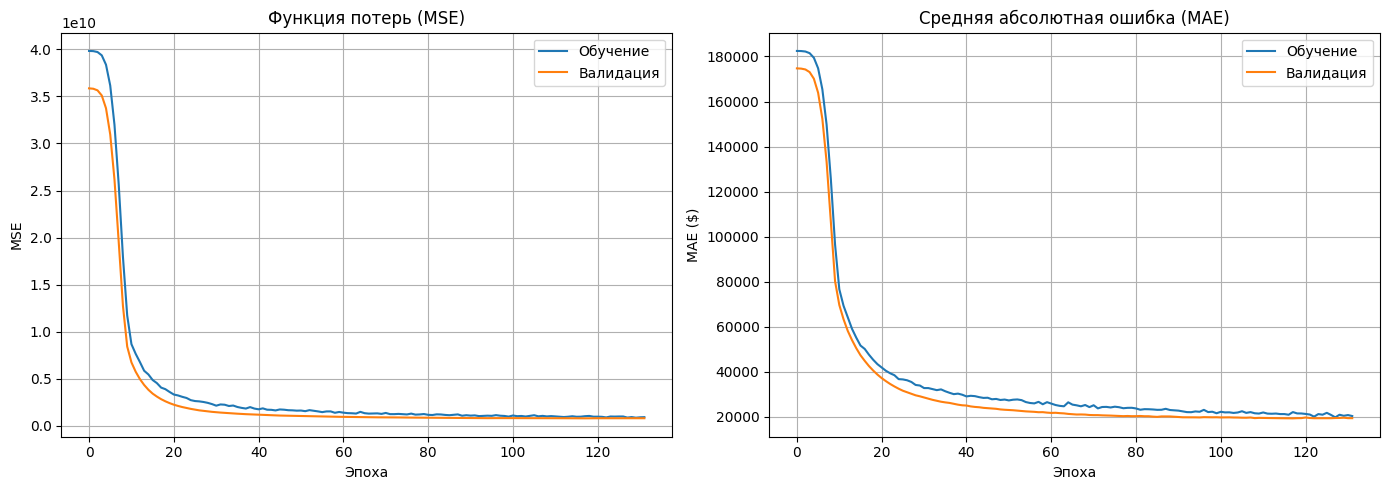

Финальные метрики на валидационной выборке:
Лучшая val_loss: 799781824.00
Лучшая val_mae:  19379.76 $


In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# График MSE (loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Обучение')
plt.plot(history.history['val_loss'], label='Валидация')
plt.title('Функция потерь (MSE)')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# График MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Обучение')
plt.plot(history.history['val_mae'], label='Валидация')
plt.title('Средняя абсолютная ошибка (MAE)')
plt.xlabel('Эпоха')
plt.ylabel('MAE ($)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Финальные значения метрик на валидации
print("Финальные метрики на валидационной выборке:")
print(f"Лучшая val_loss: {min(history.history['val_loss']):.2f}")
print(f"Лучшая val_mae:  {min(history.history['val_mae']):.2f} $")

## Предсказания на тестовой выборке и файл submission.csv

In [51]:
# Предсказания на тестовой выборке

# 1. Делаем копию test_data (чтобы не портить оригинал)
test_features = test_data.copy()

# 2. Удаляем Id — он нужен только для submission, не для модели
# Сохраняем его отдельно заранее!
test_ids = test_features['Id']               # ← сохраняем Id здесь!
test_features = test_features.drop('Id', axis=1, errors='ignore')

# 3. Повторяем ВСЕ шаги предобработки, которые были на train
# (замени на свои реальные шаги, если они отличаются)
# Пример, если ты делал так раньше:
cols_to_drop = ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
test_features = test_features.drop(columns=cols_to_drop, errors='ignore')

# Заполнение пропусков (точно как в train)
for col in test_features.select_dtypes(include=['object']).columns:
    test_features[col] = test_features[col].fillna('None')

num_cols = test_features.select_dtypes(include=['number']).columns
for col in num_cols:
    test_features[col] = test_features[col].fillna(train_data[col].median())

# 4. Кодирование категорий (самое важное!)
test_features = pd.get_dummies(test_features, drop_first=True)

# 5. Выравниваем столбцы с тем, на чём обучалась модель (X_train)
# Это решает 99% проблем
X_test = test_features.reindex(columns=X_train.columns, fill_value=0)

# 6. Масштабируем (теперь должно пройти без ошибки)
X_test_scaled = scaler.transform(X_test)

# 7. Предсказания
preds = model.predict(X_test_scaled)
preds = np.squeeze(preds)

# 8. Формируем submission — используем сохранённые Id
submission = pd.DataFrame({
    'Id': test_ids,          # ← берём из заранее сохранённой переменной
    'SalePrice': preds
})

# 9. Сохраняем
submission.to_csv('submission.csv', index=False)

# Проверки
print("submission.csv готов!")
print(submission.head(10))
print(f"Всего строк: {len(submission)}")
print(f"Min/Max предсказанной цены: {preds.min():.0f} — {preds.max():.0f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
submission.csv готов!
     Id      SalePrice
0  1461  111536.695312
1  1462   79500.531250
2  1463   99646.015625
3  1464  101417.460938
4  1465   95310.937500
5  1466   92784.312500
6  1467  109916.671875
7  1468   93110.578125
8  1469  106776.187500
9  1470  108017.585938
Всего строк: 1459
Min/Max предсказанной цены: 79501 — 240917
